
--- BASIC STATS ---
Average Wind Speed: 8.6
Max Wind Speed: 12
Average Wind Gust: 10.9
Max Wind Gust: 15
Average Temperature: 25.5

Ideal kiteboarding periods: 5


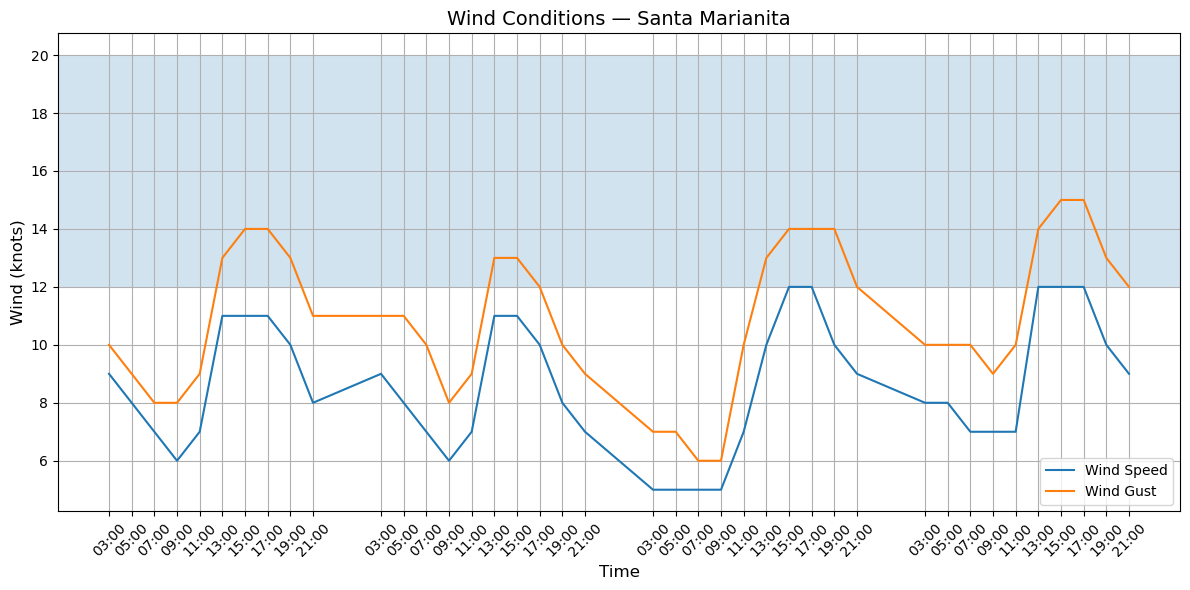

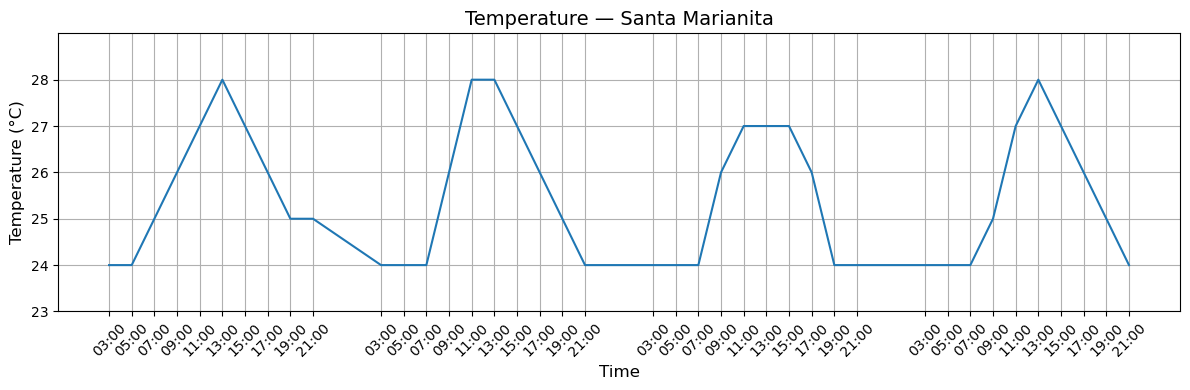

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("weather.csv")

# Convert date column
data['date'] = pd.to_datetime(data['date'])

# --- BASIC STATS ---
print("\n--- BASIC STATS ---")
print("Average Wind Speed:", round(data['wind_speed'].mean(), 2))
print("Max Wind Speed:", data['wind_speed'].max())

print("Average Wind Gust:", round(data['wind_gust'].mean(), 2))
print("Max Wind Gust:", data['wind_gust'].max())

print("Average Temperature:", round(data['temperature'].mean(), 2))

# --- ANALYSIS ---
ideal = data[(data['wind_speed'] >= 12) & (data['wind_speed'] <= 25)]
print("\nIdeal kiteboarding periods:", len(ideal))

# --- FILTER HOURS ---
desired_hours = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
filtered = data[data['date'].dt.hour.isin(desired_hours)]

# --- PLOT 1: WIND ---
plt.figure(figsize=(12,6))  # bigger plot
plt.plot(data['date'], data['wind_speed'], label="Wind Speed")
plt.plot(data['date'], data['wind_gust'], label="Wind Gust")
avg = data['wind_speed'].mean()

plt.xticks(
    filtered['date'],
    [d.strftime('%H:%M') for d in filtered['date']],
    rotation=45
)

plt.title("Wind Conditions — Santa Marianita", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Wind (knots)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
# Highlight ideal range (12–25 knots)
plt.axhspan(12, 20, alpha=0.2, label="Ideal Range (12–20 knots)")
plt.show()

# --- PLOT 2: TEMPERATURE ---
plt.figure(figsize=(12,4))  # shorter height (this already helps)

plt.plot(data['date'], data['temperature'])

plt.xticks(
    filtered['date'],
    [d.strftime('%H:%M') for d in filtered['date']],
    rotation=45
)

# Force tighter y-axis range
y_min = int(data['temperature'].min()) - 1
y_max = int(data['temperature'].max()) + 1
plt.ylim(y_min, y_max)

# Whole number ticks
import numpy as np
plt.yticks(np.arange(y_min, y_max, 1))

plt.title("Temperature — Santa Marianita", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()